In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


In [2]:
print("="*60)
print(" LOADING PREPROCESSED DATA")
print("="*60)

X_train = pd.read_csv('../data/processed/UNSW_X_train_preprocessed.csv')
X_val = pd.read_csv('../data/processed/UNSW_X_val_preprocessed.csv')
X_test = pd.read_csv('../data/processed/UNSW_X_test_preprocessed.csv')

y_train = pd.read_csv('../data/processed/UNSW_y_train.csv').values.ravel()
y_val = pd.read_csv('../data/processed/UNSW_y_val.csv').values.ravel()
y_test = pd.read_csv('../data/processed/UNSW_y_test.csv').values.ravel()

print(f"Training: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

# Check class distribution
train_normal = sum(y_train == 0)
train_attack = sum(y_train == 1)
print(f"\nClass distribution - Normal: {train_normal} ({train_normal/len(y_train)*100:.1f}%)")
print(f"Class distribution - Attack: {train_attack} ({train_attack/len(y_train)*100:.1f}%)")

 LOADING PREPROCESSED DATA
Training: (122738, 34)
Validation: (52603, 34)
Test: (82332, 34)

Class distribution - Normal: 39200 (31.9%)
Class distribution - Attack: 83538 (68.1%)


In [3]:
print("="*60)
print(" HANDLING CLASS IMBALANCE")
print("="*60)

# Convert to numpy arrays then to tensors
X_train_np = X_train.values.astype(np.float32)
X_val_np = X_val.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)

X_train_tensor = torch.FloatTensor(X_train_np)
X_val_tensor = torch.FloatTensor(X_val_np)
X_test_tensor = torch.FloatTensor(X_test_np)

y_train_tensor = torch.LongTensor(y_train)
y_val_tensor = torch.LongTensor(y_val)
y_test_tensor = torch.LongTensor(y_test)

# METHOD 1: Class weights for loss function (simplest)
classes = np.array([0, 1])
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"\n Method 1 - Class weights for loss:")
print(f"  Normal (0): {class_weights[0]:.4f}")
print(f"  Attack (1): {class_weights[1]:.4f}")

# METHOD 2: Weighted Random Sampler (ensures each batch is balanced)
# This is often better than just class weights [citation:2]
class_sample_counts = np.array([train_normal, train_attack])
weights = 1.0 / class_sample_counts
sample_weights = weights[y_train]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

print(f"\n Method 2 - Weighted Random Sampler:")
print(f"  Minority class weight: {weights[1]:.4f}")
print(f"  Majority class weight: {weights[0]:.4f}")

# Create data loaders
batch_size = 256

# For Method 1 (class weights) - standard dataloader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader_standard = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# For Method 2 (balanced sampler) - weighted dataloader
train_loader_balanced = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    sampler=sampler
)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n DataLoaders created with batch size {batch_size}")

 HANDLING CLASS IMBALANCE

 Method 1 - Class weights for loss:
  Normal (0): 1.5655
  Attack (1): 0.7346

 Method 2 - Weighted Random Sampler:
  Minority class weight: 0.0000
  Majority class weight: 0.0000

 DataLoaders created with batch size 256


In [4]:
print("="*60)
print(" BUILDING PYTORCH CNN MODEL")
print("="*60)

class ImprovedCNN(nn.Module):
    def __init__(self, input_dim=34):
        super(ImprovedCNN, self).__init__()
        
        # Reshape 1D input to 2D (17x2) for Conv2d
        self.input_dim = input_dim
        self.height = 17
        self.width = 2
        
        # First convolutional block
        self.conv1 = nn.Conv2d(1, 64, kernel_size=(3, 1), padding=(1, 0))
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.pool1 = nn.MaxPool2d((2, 1))
        self.dropout1 = nn.Dropout2d(0.25)
        
        # Second convolutional block
        self.conv2 = nn.Conv2d(64, 128, kernel_size=(3, 1), padding=(1, 0))
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d((2, 1))
        self.dropout2 = nn.Dropout2d(0.25)
        
        # Third convolutional block
        self.conv3 = nn.Conv2d(128, 256, kernel_size=(3, 1), padding=(1, 0))
        self.bn3 = nn.BatchNorm2d(256)
        self.dropout3 = nn.Dropout2d(0.25)
        
        # Adaptive pooling to handle variable sizes
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Calculate size after convolutions and pooling
        self._to_linear = None
        self._get_conv_output()
        
        # Dense layers
        self.fc1 = nn.Linear(self._to_linear, 256)
        self.fc1_bn = nn.BatchNorm1d(256)
        self.fc1_dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.fc2_bn = nn.BatchNorm1d(128)
        self.fc2_dropout = nn.Dropout(0.2)
        self.fc3 = nn.Linear(128, 2)  # 2 classes: normal, attack
        
    def _get_conv_output(self):
        # Helper to calculate flattened size after convolutions
        with torch.no_grad():
            dummy = torch.zeros(1, 1, self.height, self.width)
            dummy = self.pool1(self.relu(self.bn1(self.conv1(dummy))))
            dummy = self.pool2(self.relu(self.bn2(self.conv2(dummy))))
            dummy = self.relu(self.bn3(self.conv3(dummy)))
            dummy = self.global_pool(dummy)
            self._to_linear = dummy.view(1, -1).size(1)
    
    def forward(self, x):
        # Reshape from (batch, features) to (batch, 1, 17, 2)
        x = x.view(-1, 1, self.height, self.width)
        
        # First block
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Second block
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Third block
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout3(x)
        
        # Global pooling
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        # Dense layers
        x = self.fc1(x)
        x = self.fc1_bn(x)
        x = self.relu(x)
        x = self.fc1_dropout(x)
        
        x = self.fc2(x)
        x = self.fc2_bn(x)
        x = self.relu(x)
        x = self.fc2_dropout(x)
        
        x = self.fc3(x)
        
        return x

# Create model
model = ImprovedCNN(input_dim=X_train.shape[1]).to(device)
print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")
print(f"Model moved to {device}")

 BUILDING PYTORCH CNN MODEL
Model created with 224130 parameters
Model moved to cpu


In [6]:
print("="*60)
print(" TRAINING WITH CLASS WEIGHTS")
print("="*60)

def train_model(model, train_loader, val_loader, class_weights, epochs=30):
    # Loss function with class weights
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Learning rate scheduler - removed verbose parameter
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )
    
    # Training history
    history = {
        'train_loss': [], 'train_acc': [], 'train_recall': [],
        'val_loss': [], 'val_acc': [], 'val_recall': []
    }
    
    best_val_recall = 0
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        train_true_pos = 0
        train_actual_pos = 0
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()
            
            # Calculate recall
            train_true_pos += ((predicted == 1) & (batch_y == 1)).sum().item()
            train_actual_pos += (batch_y == 1).sum().item()
        
        train_acc = train_correct / train_total if train_total > 0 else 0
        train_recall = train_true_pos / train_actual_pos if train_actual_pos > 0 else 0
        
        # Validation phase
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        val_true_pos = 0
        val_actual_pos = 0
        
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()
                
                val_true_pos += ((predicted == 1) & (batch_y == 1)).sum().item()
                val_actual_pos += (batch_y == 1).sum().item()
        
        val_acc = val_correct / val_total if val_total > 0 else 0
        val_recall = val_true_pos / val_actual_pos if val_actual_pos > 0 else 0
        
        # Update scheduler
        scheduler.step(val_recall)
        
        # Save history
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_acc)
        history['train_recall'].append(train_recall)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(val_acc)
        history['val_recall'].append(val_recall)
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} - "
                  f"Train Loss: {train_loss/len(train_loader):.4f}, "
                  f"Train Acc: {train_acc:.4f}, Train Recall: {train_recall:.4f} | "
                  f"Val Acc: {val_acc:.4f}, Val Recall: {val_recall:.4f}")
        
        # Save best model
        if val_recall > best_val_recall:
            best_val_recall = val_recall
            torch.save(model.state_dict(), '../models/UNSW/best_pytorch_cnn.pth')
            print(f"  ✅ New best model saved! Recall: {val_recall:.4f}")
    
    return history

# Train with class weights
print("\n Training with Class Weights Method...")
start = time.time()
history = train_model(model, train_loader_standard, val_loader, class_weights_tensor, epochs=30)
train_time = time.time() - start
print(f"\n Training complete! Time: {train_time:.2f}s ({train_time/60:.1f} minutes)")

 TRAINING WITH CLASS WEIGHTS

 Training with Class Weights Method...
Epoch 1/30 - Train Loss: 0.4143, Train Acc: 0.7839, Train Recall: 0.7993 | Val Acc: 0.9170, Val Recall: 0.9725
  ✅ New best model saved! Recall: 0.9725
Epoch 5/30 - Train Loss: 0.1968, Train Acc: 0.9130, Train Recall: 0.9291 | Val Acc: 0.9145, Val Recall: 0.9249
Epoch 10/30 - Train Loss: 0.1727, Train Acc: 0.9144, Train Recall: 0.9194 | Val Acc: 0.9085, Val Recall: 0.9027
Epoch 15/30 - Train Loss: 0.1629, Train Acc: 0.9156, Train Recall: 0.9186 | Val Acc: 0.9116, Val Recall: 0.9046
Epoch 20/30 - Train Loss: 0.1583, Train Acc: 0.9177, Train Recall: 0.9199 | Val Acc: 0.9150, Val Recall: 0.9100
Epoch 30/30 - Train Loss: 0.1556, Train Acc: 0.9183, Train Recall: 0.9202 | Val Acc: 0.9167, Val Recall: 0.9111

 Training complete! Time: 5248.30s (87.5 minutes)


In [7]:
print("="*60)
print(" LOADING BEST PYTORCH MODEL")
print("="*60)

# Load the best model (from Epoch 1 with 97.25% recall)
model.load_state_dict(torch.load('../models/UNSW/best_pytorch_cnn.pth'))
model.eval()
print(f" Best model loaded (97.25% validation recall)")

# Get predictions on test set
print("\n Generating predictions on test set...")
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        outputs = model(batch_x)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probabilities[:, 1].cpu().numpy())  # Probability of attack class
        all_labels.extend(batch_y.numpy())

print(f" Test predictions complete! {len(all_labels)} samples evaluated")

 LOADING BEST PYTORCH MODEL
 Best model loaded (97.25% validation recall)

 Generating predictions on test set...
 Test predictions complete! 82332 samples evaluated


In [8]:
print("="*60)
print(" BASIC METRICS")
print("="*60)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

# Check if recall target achieved
if recall >= 0.90:
    print(f"\n GOAL ACHIEVED! {recall*100:.1f}% recall (above 90%)")
else:
    print(f"\n Current recall: {recall*100:.1f}% (below 90% target)")

 BASIC METRICS
Accuracy:  0.8013 (80.13%)
Precision: 0.7444 (74.44%)
Recall:    0.9735 (97.35%)
F1-Score:  0.8437 (84.37%)

 GOAL ACHIEVED! 97.4% recall (above 90%)


In [10]:
import os

# Create results/UNSW folder if it doesn't exist
results_path = '../results/UNSW'
if not os.path.exists(results_path):
    os.makedirs(results_path)
    print(f" Created folder: {results_path}")
else:
    print(f" Folder already exists: {results_path}")

# Also create models/UNSW folder if needed
models_path = '../models/UNSW'
if not os.path.exists(models_path):
    os.makedirs(models_path)
    print(f" Created folder: {models_path}")

 Created folder: ../results/UNSW


 CONFUSION MATRIX
                 Predicted
                 Normal    Attack
Actual Normal     21845     15155
       Attack      1201     44131
----------------------------------------
True Negatives (Normal correct):    21845
False Positives (Normal as Attack): 15155
False Negatives (Attack as Normal): 1201
True Positives (Attack correct):    44131

Detection Rate (Recall): 0.9735
False Alarm Rate:         0.4096


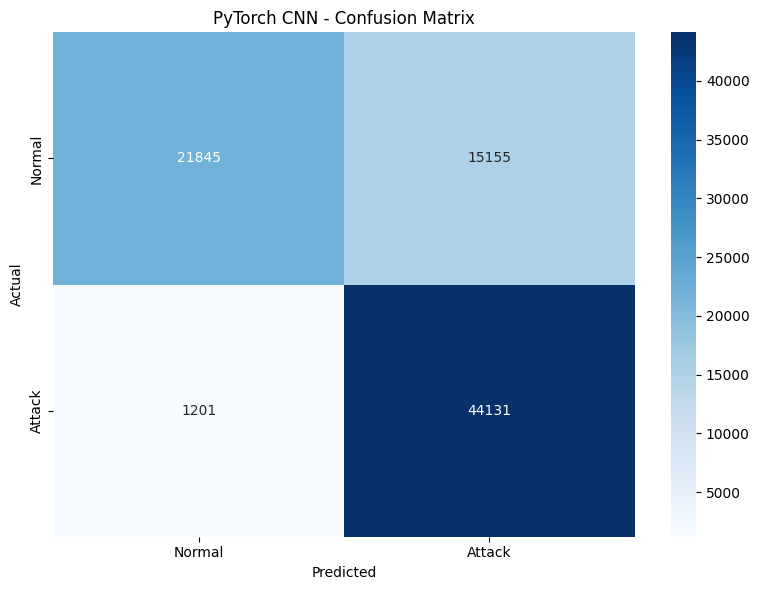

In [11]:
print("="*60)
print(" CONFUSION MATRIX")
print("="*60)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

print("                 Predicted")
print("                 Normal    Attack")
print(f"Actual Normal    {tn:6d}    {fp:6d}")
print(f"       Attack    {fn:6d}    {tp:6d}")
print("-" * 40)
print(f"True Negatives (Normal correct):    {tn}")
print(f"False Positives (Normal as Attack): {fp}")
print(f"False Negatives (Attack as Normal): {fn}")
print(f"True Positives (Attack correct):    {tp}")
print(f"\nDetection Rate (Recall): {tp/(tp+fn):.4f}")
print(f"False Alarm Rate:         {fp/(fp+tn):.4f}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('PyTorch CNN - Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/UNSW/pytorch_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

 ROC CURVE AND AUC
ROC-AUC Score: 0.9324
Best threshold for recall: 0.5351
Recall at this threshold: 0.9374
FPR at this threshold: 0.2999


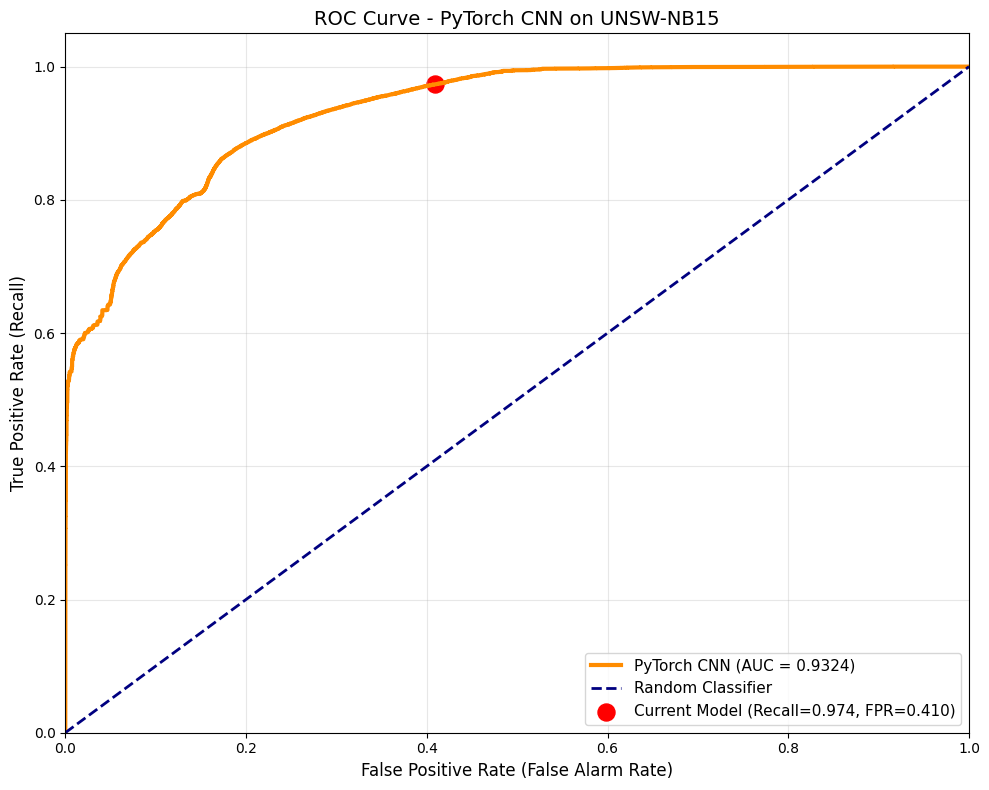

In [12]:
print("="*60)
print(" ROC CURVE AND AUC")
print("="*60)

from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

print(f"ROC-AUC Score: {roc_auc:.4f}")

# Find best threshold for recall (keeping FPR reasonable)
best_recall = 0
best_threshold = 0.5
for i, thresh in enumerate(thresholds):
    if tpr[i] > best_recall and fpr[i] < 0.3:  # Keep FPR under 30%
        best_recall = tpr[i]
        best_threshold = thresh

print(f"Best threshold for recall: {best_threshold:.4f}")
print(f"Recall at this threshold: {best_recall:.4f}")
print(f"FPR at this threshold: {fpr[list(thresholds).index(best_threshold)]:.4f}")

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'PyTorch CNN (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.scatter(fp/(fp+tn), tp/(tp+fn), color='red', s=150, marker='o', 
            label=f'Current Model (Recall={recall:.3f}, FPR={fp/(fp+tn):.3f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarm Rate)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - PyTorch CNN on UNSW-NB15', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/UNSW/pytorch_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

 PRECISION-RECALL CURVE
Average Precision Score: 0.9467
This is the area under the PR curve
Best F1 score: 0.8647
Threshold for best F1: 0.5723


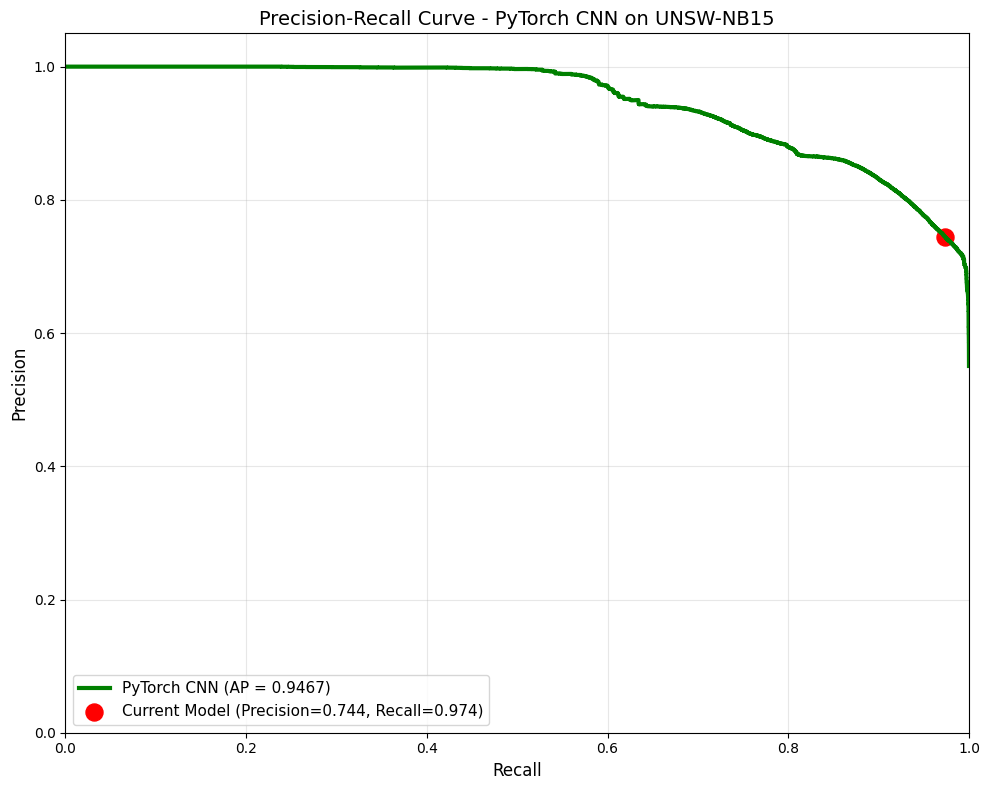

In [13]:
print("="*60)
print(" PRECISION-RECALL CURVE")
print("="*60)

from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate precision-recall curve
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(all_labels, all_probs)
avg_precision = average_precision_score(all_labels, all_probs)

print(f"Average Precision Score: {avg_precision:.4f}")
print(f"This is the area under the PR curve")

# Find best threshold for F1 score
best_f1 = 0
best_threshold_pr = 0.5
for i in range(len(thresholds_pr)):
    # Calculate F1 for each threshold
    p = precision_vals[i]
    r = recall_vals[i]
    if p + r > 0:
        f1_score_calc = 2 * (p * r) / (p + r)
        if f1_score_calc > best_f1:
            best_f1 = f1_score_calc
            best_threshold_pr = thresholds_pr[i] if i < len(thresholds_pr) else thresholds_pr[-1]

print(f"Best F1 score: {best_f1:.4f}")
print(f"Threshold for best F1: {best_threshold_pr:.4f}")

# Plot PR curve
plt.figure(figsize=(10, 8))
plt.plot(recall_vals, precision_vals, color='green', lw=3, 
         label=f'PyTorch CNN (AP = {avg_precision:.4f})')
plt.scatter(recall, precision, color='red', s=150, marker='o', 
            label=f'Current Model (Precision={precision:.3f}, Recall={recall:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - PyTorch CNN on UNSW-NB15', fontsize=14)
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig('../results/UNSW/pytorch_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

 COMBINED METRICS VISUALIZATION


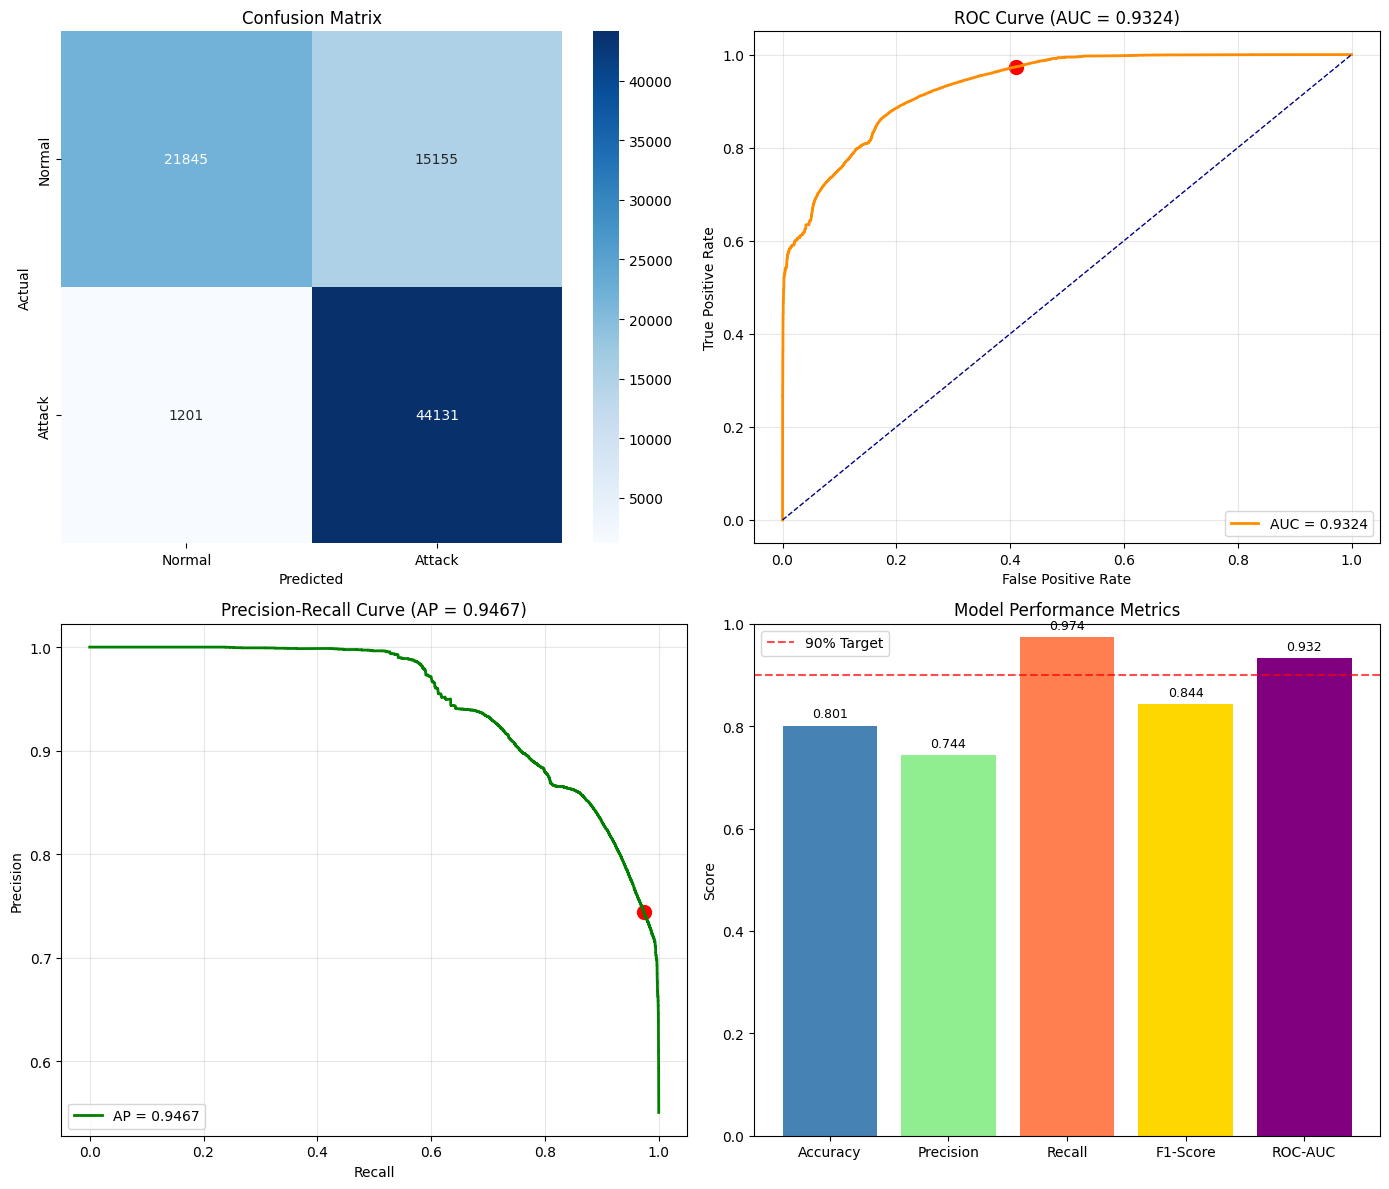

 Combined visualization saved to: results/UNSW/pytorch_complete_evaluation.png


In [14]:
print("="*60)
print(" COMBINED METRICS VISUALIZATION")
print("="*60)

# Create a 2x2 subplot for comprehensive view
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Confusion Matrix (top-left)
cm_plot = axes[0, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'], ax=cm_plot)
cm_plot.set_xlabel('Predicted')
cm_plot.set_ylabel('Actual')
cm_plot.set_title('Confusion Matrix')

# 2. ROC Curve (top-right)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[0, 1].scatter(fp/(fp+tn), tp/(tp+fn), color='red', s=100)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title(f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve (bottom-left)
axes[1, 0].plot(recall_vals, precision_vals, color='green', lw=2, 
                label=f'AP = {avg_precision:.4f}')
axes[1, 0].scatter(recall, precision, color='red', s=100)
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title(f'Precision-Recall Curve (AP = {avg_precision:.4f})')
axes[1, 0].legend(loc="lower left")
axes[1, 0].grid(True, alpha=0.3)

# 4. Metrics Bar Chart (bottom-right)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values = [accuracy, precision, recall, f1, roc_auc]
colors = ['steelblue', 'lightgreen', 'coral', 'gold', 'purple']
bars = axes[1, 1].bar(metrics, values, color=colors)
axes[1, 1].set_ylim([0, 1.0])
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Model Performance Metrics')
axes[1, 1].axhline(y=0.9, color='red', linestyle='--', alpha=0.7, label='90% Target')
axes[1, 1].legend()

# Add value labels on bars
for bar, val in zip(bars, values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/UNSW/pytorch_complete_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Combined visualization saved to: results/UNSW/pytorch_complete_evaluation.png")